In [1]:
import salishsea_tools
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import xarray as xr
import netCDF4 as nc
from salishsea_tools import geo_tools

In [4]:
# Puget Sound boundaries
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/PennCove_30d_2bound/new_compw_forward_01jan18/ariane_positions_quantitative.nc'
dataf = xr.open_dataset(outputf)


root_dir = '/ocean/ghoeven/MOAD/ariane-2.3.0_03'
qnt_dirs = []

for dirpath, dirnames, _ in os.walk(root_dir):
    for dirname in dirnames:
        if dirname.endswith('QNT'):
            qnt_dirs.append(os.path.join(dirpath, dirname))

qnt_dirs.append('/ocean/ghoeven/MOAD/ariane-2.3.0_03/quantExamplePennCove')

all_boundaries = np.empty((1,7))

for qnt_dir in qnt_dirs:
    sections = pd.read_csv(qnt_dir + '/sections.txt', sep=' ', names=list(range(30)))
    sections = sections[~sections.apply(lambda row: row.astype(str).str.contains('Surface')).any(axis=1)]
    sections = sections.apply(lambda row: row.dropna().values[:-1].astype(float), axis=1)
    sections = pd.DataFrame(sections.tolist()).to_numpy()
    
    all_boundaries =np.concatenate((all_boundaries, sections),axis=0)



/tmp/ipykernel_36576/1486675687.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dataf = xr.open_dataset(outputf)


[174. 187.] [121. 121.]
[108. 109.] [30. 30.]
[125. 132.] [25. 25.]
[129. 129.] [47. 48.]
[275. 281.] [177. 177.]
[150. 158.] [31. 31.]
[241. 243.] [207. 207.]
[243. 247.] [209. 209.]
[247. 252.] [211. 211.]
[252. 256.] [213. 213.]
[256. 259.] [215. 215.]
[259. 261.] [217. 217.]
[243. 243.] [207. 209.]
[247. 247.] [209. 211.]
[252. 252.] [211. 213.]
[256. 256.] [213. 215.]
[259. 259.] [215. 217.]
[242. 248.] [154. 154.]
[259. 272.] [141. 141.]
[100. 107.] [79. 79.]
[282. 282.] [210. 216.]
[275. 275.] [213. 216.]
[189. 200.] [21. 21.]
[107. 109.] [19. 19.]
[122. 126.] [20. 20.]
[242. 246.] [137. 137.]
[121. 121.] [71. 72.]
[241. 243.] [73. 73.]
[243. 245.] [74. 74.]
[245. 246.] [75. 75.]
[241. 241.] [72. 73.]
[243. 243.] [73. 74.]
[245. 245.] [74. 75.]
[275. 281.] [177. 177.]
[242. 248.] [154. 154.]
[100. 107.] [79. 79.]
[241. 243.] [207. 207.]
[243. 247.] [209. 209.]
[247. 252.] [211. 211.]
[252. 256.] [213. 213.]
[256. 259.] [215. 215.]
[259. 261.] [217. 217.]
[243. 243.] [207. 209.]


[]

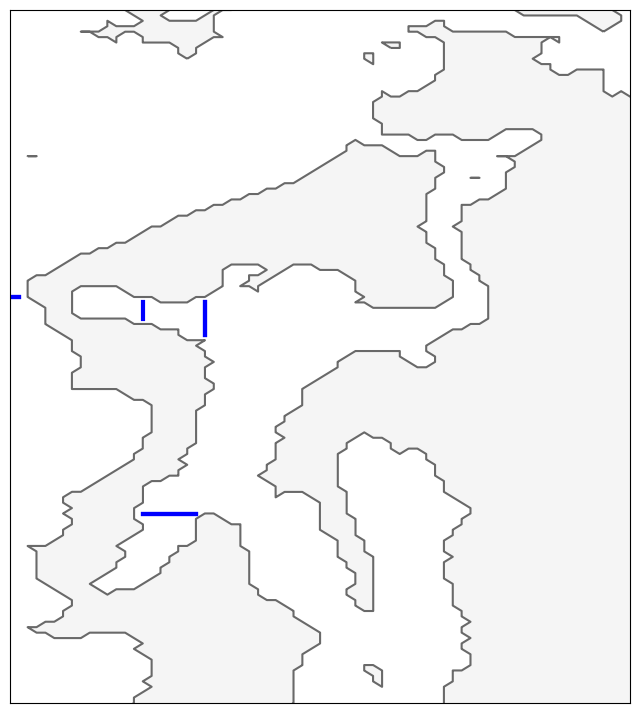

In [13]:
# Load grid and mask files
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_ylim([142, 270])
ax.set_xlim([260, 330])
# Overlay domain landmask and coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='dimgray')

# Plot each boundary from all_boundaries array
for n in range(all_boundaries.shape[0]-1):
    n = n+1
    if (all_boundaries[n, 3:5] < 0).any():
        all_boundaries[n,3:5] = -all_boundaries[n,3:5]
    if (all_boundaries[n, 1:3] < 0).any():
        all_boundaries[n, 1:3] = -all_boundaries[n, 1:3]
    print(all_boundaries[n, 1:3]-1, all_boundaries[n,3:5]-1)
    ax.plot(all_boundaries[n, 1:3]-1, all_boundaries[n,3:5]-1, linewidth=3, c='b')
ax.scatter(229, 69, c='r', s=10)
ax.set_xticks([])
ax.set_yticks([])
